In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Aarav@2207",
    database="retail_store_ml"
)

query = """
SELECT
    `Customer ID`,
    COUNT(DISTINCT Invoice) AS Frequency,
    SUM(Quantity) AS TotalQuantity,
    AVG(Price) AS AvgPrice,
    COUNT(DISTINCT StockCode) AS ProductCount,
    SUM(Quantity * Price) AS TotalSpend
FROM retail
WHERE `Customer ID` IS NOT NULL
  AND Quantity > 0
  AND Price > 0
GROUP BY `Customer ID`;
"""

df = pd.read_sql(query, conn)
conn.close()

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_45000\3250028664.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer ID,Frequency,TotalQuantity,AvgPrice,ProductCount,TotalSpend
0,0,1428,841128.0,6.288362,3301,3.510553e+06
1,12346,1,148430.0,1.040000,1,1.543672e+05
2,12347,7,4916.0,2.644011,103,8.620000e+03
3,12348,4,4682.0,5.764839,22,3.594480e+03
4,12349,1,1262.0,8.289041,73,3.515100e+03


In [3]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
threshold = df['TotalSpend'].quantile(0.75)
df['HighValue'] = df['TotalSpend'] >= threshold.astype(int)
print(threshold)

3324.1200000000003


In [5]:
df['HighValue'].value_counts()

HighValue
False    3254
True     1085
Name: count, dtype: int64

In [6]:
X = df[
    [
        "Frequency",
        "TotalQuantity",
        "AvgPrice",
        "ProductCount"
    ]
]

Y = df["HighValue"]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8, random_state= 42, stratify=Y)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000, random_state = 42)
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.923963133640553
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       651
        True       0.90      0.78      0.84       217

    accuracy                           0.92       868
   macro avg       0.92      0.88      0.89       868
weighted avg       0.92      0.92      0.92       868



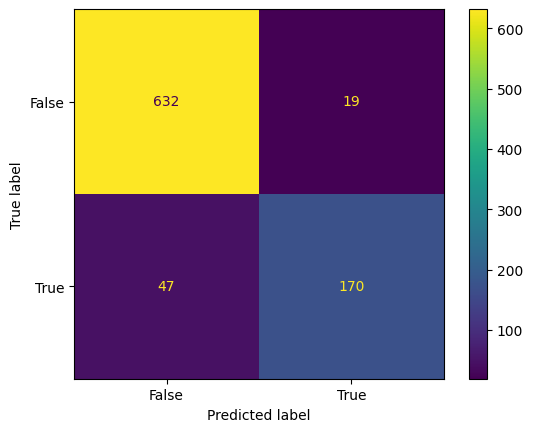

In [11]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    "C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42,max_iter=1000),params ,cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train_scaled, Y_train)

KeyboardInterrupt: 

In [ ]:
grid_lr.best_score_

np.float64(0.9403603342110174)

In [ ]:
grid_lr.best_params_

{'C': 10, 'solver': 'liblinear'}

In [ ]:
best_model = grid_lr.best_estimator_

Y_pred = best_model.predict(X_test_scaled)

In [ ]:
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9493087557603687
              precision    recall  f1-score   support

       False       0.99      0.95      0.97       697
        True       0.82      0.95      0.88       171

    accuracy                           0.95       868
   macro avg       0.90      0.95      0.92       868
weighted avg       0.95      0.95      0.95       868



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 100)
model.fit(X_train_scaled , Y_train)
Y_test = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9481566820276498
              precision    recall  f1-score   support

       False       0.97      0.96      0.97       680
        True       0.86      0.91      0.88       188

    accuracy                           0.95       868
   macro avg       0.92      0.93      0.93       868
weighted avg       0.95      0.95      0.95       868



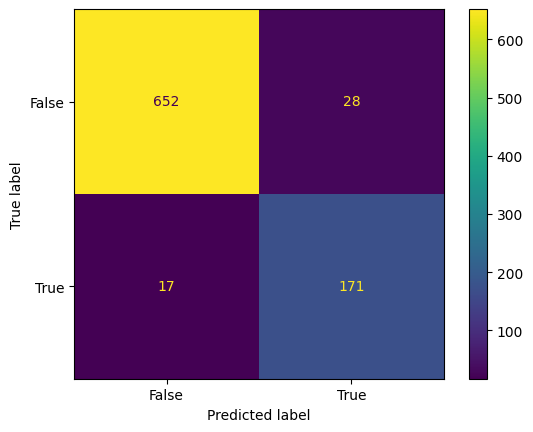

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
k_values = range(1,21)
acc_score = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test)
    score = accuracy_score(Y_test,Y_pred)
    acc_score.append(score)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeigh

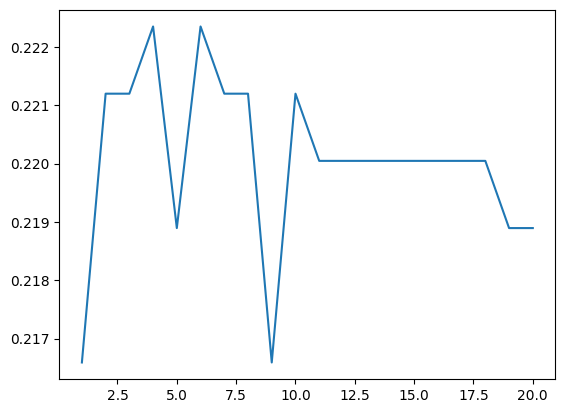

In [ ]:
plt.plot(k_values , acc_score)
plt.show()

In [ ]:
best_k = k_values[acc_score.index(max(acc_score))]
print(best_k)

4


In [ ]:
max(acc_score)

0.22235023041474655

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]}

grid_knn = GridSearchCV(KNeighborsClassifier(), params, scoring = "accuracy", cv=5, n_jobs=-1)
grid_knn.fit(X_train_scaled,Y_train)
Y_pred = grid_knn.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
grid_knn.best_params_

{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}

In [ ]:
grid_knn.best_score_

np.float64(0.9354628573798023)

In [ ]:
best_model = grid_knn.best_estimator_
Y_pred = best_model.predict(X_test)

print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.19700460829493088
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       697
        True       0.20      1.00      0.33       171

    accuracy                           0.20       868
   macro avg       0.10      0.50      0.16       868
weighted avg       0.04      0.20      0.06       868



c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

model.fit(X_train_scaled , Y_train)
Y_test = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.19700460829493088
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       697
        True       0.20      1.00      0.33       171

    accuracy                           0.20       868
   macro avg       0.10      0.50      0.16       868
weighted avg       0.04      0.20      0.06       868



c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

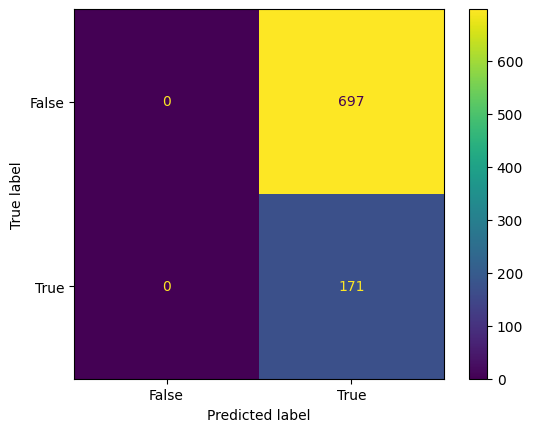

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
Y_proba = model.predict_proba(X_test_scaled)
Y_proba[:10]


array([[9.99820226e-001, 1.79773862e-004],
       [9.99949720e-001, 5.02795758e-005],
       [7.31764320e-001, 2.68235680e-001],
       [9.99718203e-001, 2.81796773e-004],
       [9.99932887e-001, 6.71128602e-005],
       [9.62143929e-009, 9.99999990e-001],
       [9.99941651e-001, 5.83492229e-005],
       [9.99908253e-001, 9.17473770e-005],
       [9.99806291e-001, 1.93708584e-004],
       [8.38944053e-164, 1.00000000e+000]])

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}
grid_nb = GridSearchCV(GaussianNB(), params, scoring = "accuracy", cv=5, n_jobs=-1)
grid_nb.fit(X_train_scaled,Y_train)
Y_pred = grid_nb.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


In [ ]:
grid_nb.best_params_

{'var_smoothing': 1e-11}

In [ ]:
grid_nb.best_score_

np.float64(0.9152949225633902)

In [ ]:
best_model = grid_nb.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.19700460829493088
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       697
        True       0.20      1.00      0.33       171

    accuracy                           0.20       868
   macro avg       0.10      0.50      0.16       868
weighted avg       0.04      0.20      0.06       868



c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classifi

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9147465437788018
              precision    recall  f1-score   support

       False       0.97      0.92      0.95       697
        True       0.74      0.88      0.80       171

    accuracy                           0.91       868
   macro avg       0.85      0.90      0.87       868
weighted avg       0.92      0.91      0.92       868



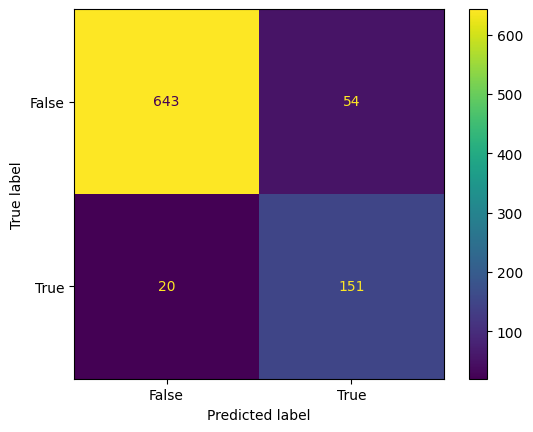

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(importance)

        Features  Importance
1  TotalQuantity    0.802105
2       AvgPrice    0.120122
3   ProductCount    0.045460
0      Frequency    0.032313


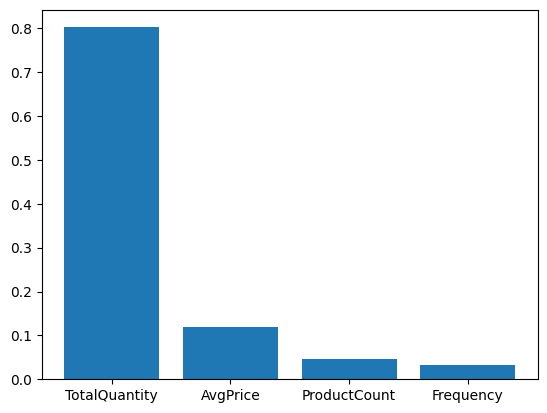

In [ ]:
plt.bar(importance['Features'], importance['Importance'])
plt.show()

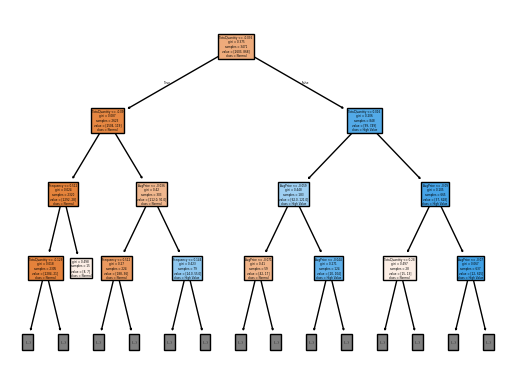

In [ ]:
from sklearn.tree import plot_tree
plot_tree(best_model, feature_names=X.columns, class_names=["Normal", "High Value"], filled=True, max_depth=3)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params={"max_depth": [2, 3, 5, 7, 10, None], "min_samples_split": [2, 5, 10, 20], "min_samples_leaf": [1, 2, 5, 10], "criterion": ["gini", "entropy"] }

grid_dtc = GridSearchCV(DecisionTreeClassifier(random_state = 42), params, scoring='accuracy', cv=5)
grid_dtc.fit(X_train,Y_train)
Y_pred = grid_dtc.predict(X_test)

In [ ]:
grid_dtc.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'min_samples_leaf': 10,
 'min_samples_split': 2}

In [ ]:
grid_dtc.best_score_

np.float64(0.9455476540957436)

In [ ]:
best_model = grid_dtc.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9297235023041475
              precision    recall  f1-score   support

       False       0.98      0.94      0.96       697
        True       0.78      0.91      0.84       171

    accuracy                           0.93       868
   macro avg       0.88      0.92      0.90       868
weighted avg       0.94      0.93      0.93       868



In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9285714285714286
              precision    recall  f1-score   support

       False       0.98      0.93      0.95       697
        True       0.76      0.93      0.84       171

    accuracy                           0.93       868
   macro avg       0.87      0.93      0.90       868
weighted avg       0.94      0.93      0.93       868



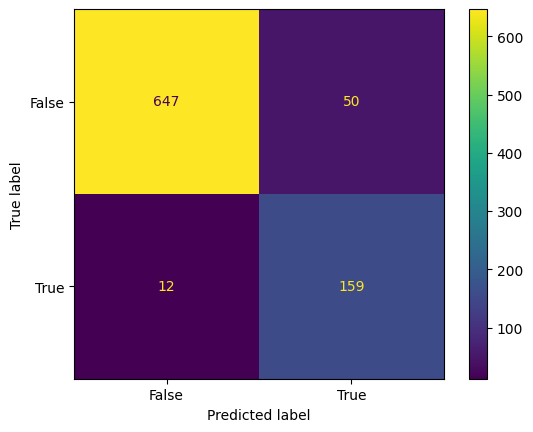

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(importance)

        Features  Importance
1  TotalQuantity    0.573384
0      Frequency    0.226735
3   ProductCount    0.100375
2       AvgPrice    0.099507


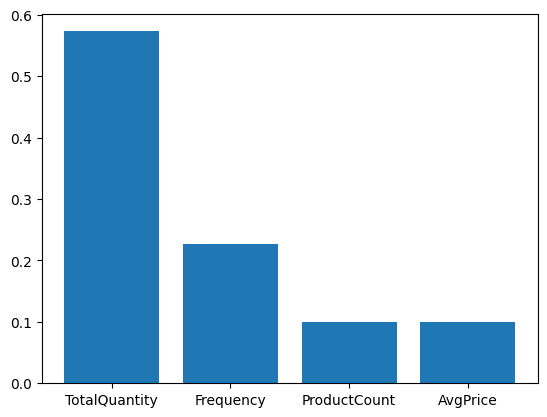

In [ ]:
plt.bar(importance['Features'], importance['Importance'])
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators": [100, 200, 300], "max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 5]}

grid_rfc = GridSearchCV(RandomForestClassifier(random_state = 42, n_jobs=-1), params, scoring='accuracy', cv=5, n_jobs=-1)
grid_rfc.fit(X_train,Y_train)
Y_pred = grid_rfc.predict(X_test)

In [ ]:
grid_rfc.best_score_

np.float64(0.9524628366471088)

In [ ]:
grid_rfc.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
best_model = grid_rfc.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9331797235023042
              precision    recall  f1-score   support

       False       0.98      0.93      0.96       697
        True       0.78      0.93      0.85       171

    accuracy                           0.93       868
   macro avg       0.88      0.93      0.90       868
weighted avg       0.94      0.93      0.94       868



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators = 200, random_state = 42, learning_rate = 0.1)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9366359447004609
              precision    recall  f1-score   support

       False       0.98      0.94      0.96       697
        True       0.78      0.94      0.85       171

    accuracy                           0.94       868
   macro avg       0.88      0.94      0.91       868
weighted avg       0.94      0.94      0.94       868



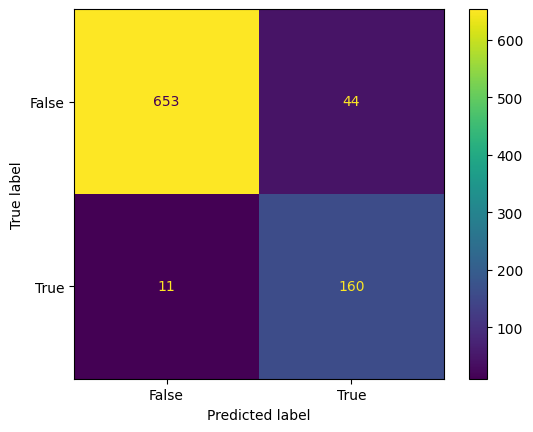

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(importance)

        Features  Importance
1  TotalQuantity    0.640707
2       AvgPrice    0.206536
0      Frequency    0.148970
3   ProductCount    0.003787


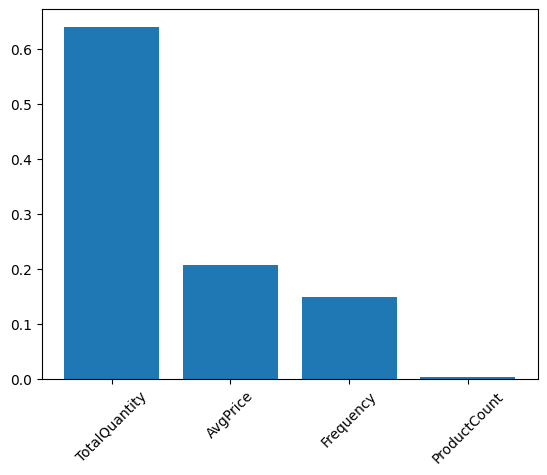

In [ ]:
plt.bar(importance['Features'], importance['Importance'])
plt.xticks(rotation = 45)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1]
}
grid_abc = GridSearchCV(AdaBoostClassifier(random_state = 42), params, scoring='accuracy', cv=5, n_jobs=-1)
grid_abc.fit(X_train,Y_train)
Y_pred = grid_abc.predict(X_test)

In [ ]:
grid_abc.best_score_

np.float64(0.9547674828436963)

In [ ]:
grid_abc.best_params_

{'learning_rate': 0.5, 'n_estimators': 300}

In [ ]:
best_model = grid_abc.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9308755760368663
              precision    recall  f1-score   support

       False       0.98      0.93      0.96       697
        True       0.77      0.93      0.84       171

    accuracy                           0.93       868
   macro avg       0.87      0.93      0.90       868
weighted avg       0.94      0.93      0.93       868



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators = 100, random_state = 42, learning_rate = 0.1, max_depth = 3)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9320276497695853
              precision    recall  f1-score   support

       False       0.98      0.93      0.96       697
        True       0.77      0.94      0.84       171

    accuracy                           0.93       868
   macro avg       0.88      0.93      0.90       868
weighted avg       0.94      0.93      0.93       868



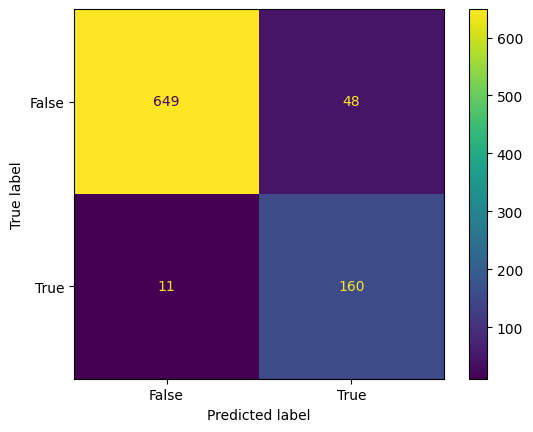

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(importance)

        Features  Importance
1  TotalQuantity    0.868436
2       AvgPrice    0.081327
0      Frequency    0.038967
3   ProductCount    0.011270


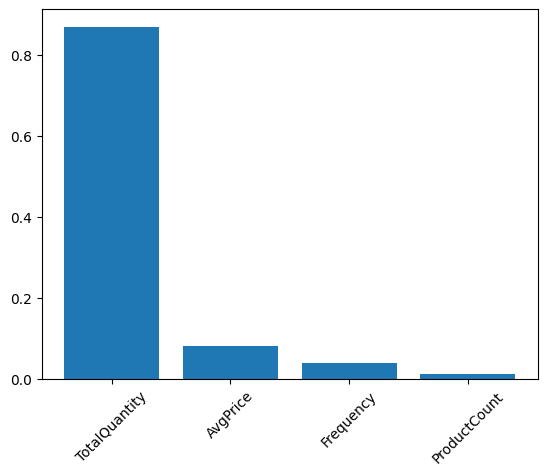

In [ ]:
plt.bar(importance['Features'], importance['Importance'])
plt.xticks(rotation = 45)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 5], "min_samples_split": [2, 5, 10]}

grid_gbc = GridSearchCV(GradientBoostingClassifier(random_state = 42), params, scoring='accuracy', cv=5, n_jobs=-1)
grid_gbc.fit(X_train,Y_train)
Y_pred = grid_gbc.predict(X_test)

In [ ]:
grid_gbc.best_score_

np.float64(0.9527514357390169)

In [ ]:
grid_gbc.best_params_

{'learning_rate': 0.05,
 'max_depth': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [ ]:
best_model = grid_gbc.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9274193548387096
              precision    recall  f1-score   support

       False       0.98      0.93      0.95       697
        True       0.76      0.93      0.83       171

    accuracy                           0.93       868
   macro avg       0.87      0.93      0.89       868
weighted avg       0.94      0.93      0.93       868



AdaBoost: focuses more on observations that previous weak learners misclassified.

Gradient Boosting: each new tree is trained to reduce the errors/residuals of the existing ensemble.

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, eval_metric="logloss", random_state=42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9193548387096774
              precision    recall  f1-score   support

       False       0.98      0.92      0.95       697
        True       0.73      0.92      0.82       171

    accuracy                           0.92       868
   macro avg       0.86      0.92      0.88       868
weighted avg       0.93      0.92      0.92       868



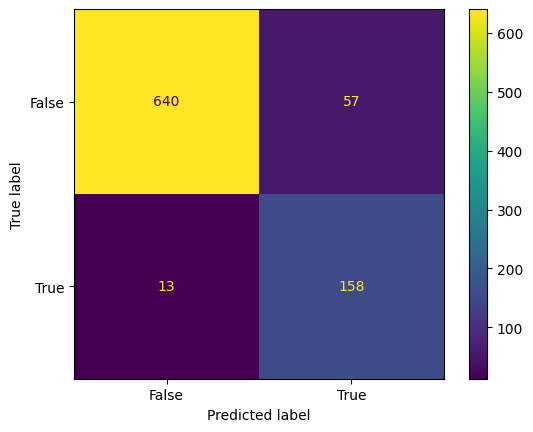

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(importance)

        Features  Importance
1  TotalQuantity    0.733117
0      Frequency    0.137021
2       AvgPrice    0.093534
3   ProductCount    0.036328


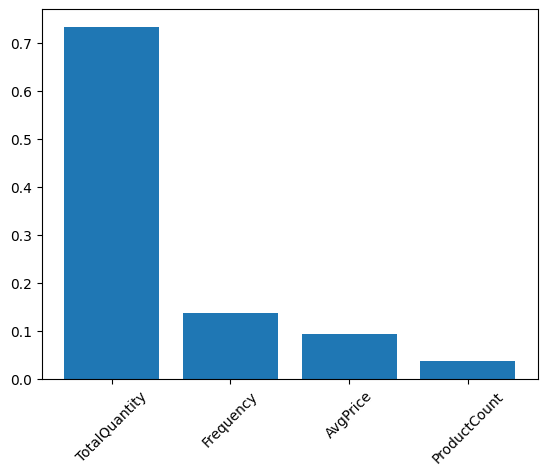

In [ ]:
plt.bar(importance['Features'], importance['Importance'])
plt.xticks(rotation = 45)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params ={"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 5], "subsample": [0.8, 1.0]}

grid_xgbc = GridSearchCV(XGBClassifier(eval_metric = "logloss" ,random_state = 42), params, scoring='accuracy', cv=5, n_jobs=-1)
grid_xgbc.fit(X_train,Y_train)
Y_pred = grid_xgbc.predict(X_test)

In [ ]:
grid_xgbc.best_score_

np.float64(0.9544809570211268)

In [ ]:
grid_xgbc.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [ ]:
best_model = grid_xgbc.best_estimator_
Y_pred = best_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9193548387096774
              precision    recall  f1-score   support

       False       0.98      0.92      0.95       697
        True       0.74      0.92      0.82       171

    accuracy                           0.92       868
   macro avg       0.86      0.92      0.88       868
weighted avg       0.93      0.92      0.92       868



In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train_scaled , Y_train)
Y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9596774193548387
              precision    recall  f1-score   support

       False       0.99      0.96      0.97       697
        True       0.85      0.96      0.90       171

    accuracy                           0.96       868
   macro avg       0.92      0.96      0.94       868
weighted avg       0.96      0.96      0.96       868



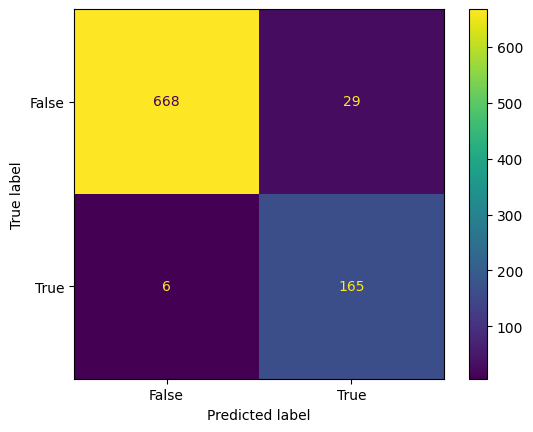

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [ ]:
kernels = ["linear", 'rbf', 'poly', 'sigmoid']
acc_score = []
for kernel in kernels:
    model = SVC(kernel=kernel, C=1, gamma='scale')
    model.fit(X_train_scaled,Y_train)
    Y_pred = model.predict(X_test_scaled)

    score = accuracy_score(Y_test,Y_pred)       
    acc_score.append(score)

In [ ]:
print(acc_score)

[0.9504608294930875, 0.9596774193548387, 0.9009216589861752, 0.8548387096774194]


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel": ["linear", "rbf", "poly"]
}

grid_svc = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svc.fit(X_train_scaled, Y_train)

print("Best Params:", grid_svc.best_params_)
print("Best CV Accuracy:", grid_svc.best_score_)

Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9472755167623825


In [ ]:
best_model = grid_svc.best_estimator_
Y_pred = best_model.predict(X_test_scaled)
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.9435483870967742
              precision    recall  f1-score   support

       False       0.99      0.94      0.96       697
        True       0.80      0.95      0.87       171

    accuracy                           0.94       868
   macro avg       0.89      0.95      0.92       868
weighted avg       0.95      0.94      0.95       868



In [13]:
X = df[
    [
        "Frequency",
        "TotalQuantity",
        "AvgPrice",
        "ProductCount"
    ]
]

In [15]:
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(n_clusters = 4, linkage='ward')
labels = model.fit_predict(X_test_scaled)
print(labels)

[2 1 2 1 1 0 1 1 1 0 2 1 1 2 1 1 1 1 1 0 1 0 1 2 1 1 1 1 1 1 2 1 1 1 1 0 1
 1 2 1 1 1 1 1 1 1 1 2 2 2 1 0 1 1 1 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 1 1 1
 2 2 1 1 2 0 1 2 1 1 1 1 2 2 1 2 0 1 2 1 2 1 1 2 1 1 2 1 1 1 2 2 2 1 1 2 2
 0 1 2 1 1 2 2 1 2 1 2 1 2 1 1 1 2 1 0 2 2 1 1 1 2 1 1 2 2 2 1 1 1 1 1 2 2
 2 2 1 1 2 0 2 2 2 1 1 1 2 2 1 1 1 1 1 1 2 2 2 2 1 1 1 2 1 1 2 1 2 1 2 1 1
 1 1 2 1 1 1 0 1 2 2 1 1 1 1 2 2 1 1 2 1 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 1 1 1 2 1 1 1 1 2 2 2 2 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1
 1 1 1 2 2 2 2 2 2 1 1 1 1 1 2 1 1 1 0 2 1 2 1 1 1 1 1 2 1 1 2 2 1 1 2 1 1
 2 2 2 1 2 2 1 1 1 1 1 1 1 1 2 2 2 2 1 0 1 2 1 1 2 1 1 1 1 1 1 1 0 2 2 2 2
 2 2 2 2 2 1 2 2 0 1 2 1 1 2 0 1 1 2 1 1 1 1 1 1 1 2 1 1 1 2 1 1 1 1 2 2 2
 1 2 2 1 1 1 1 1 1 1 2 1 1 2 2 0 2 2 1 2 2 1 2 2 1 1 1 2 1 2 1 0 1 1 0 1 1
 1 1 2 1 1 1 1 1 1 2 1 1 2 1 2 1 2 2 1 2 1 1 2 2 1 1 2 1 1 2 2 2 1 1 1 1 2
 2 1 1 1 1 1 2 1 1 1 1 2 1 2 0 1 1 1 2 1 1 2 2 1 1 2 1 1 1 2 0 2 1 1 1 1 2
 1 2 2 2 2 2 0 1 2 1 1 2 

In [16]:
np.bincount(labels)

array([ 37, 545, 285,   1])

In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_test_scaled, labels)
print(score)

0.4944951809418759


In [32]:
silhouette = []
k_values =  range(2,21)
for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_test_scaled)

    score = silhouette_score(X_test_scaled, labels)
    silhouette.append(score)

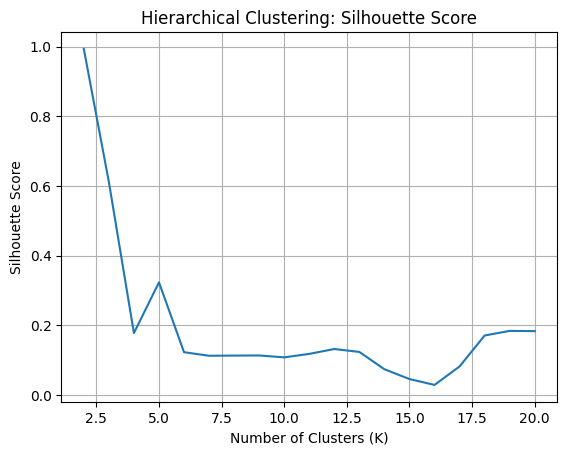

In [54]:
plt.plot(k_values, silhouette)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering: Silhouette Score")

plt.grid()
plt.show()

In [34]:
best_k = k_values[silhouette.index(max(silhouette))]
print("best k value:", best_k)

best k value: 2


In [28]:
max(silhouette)

0.9932132962849393

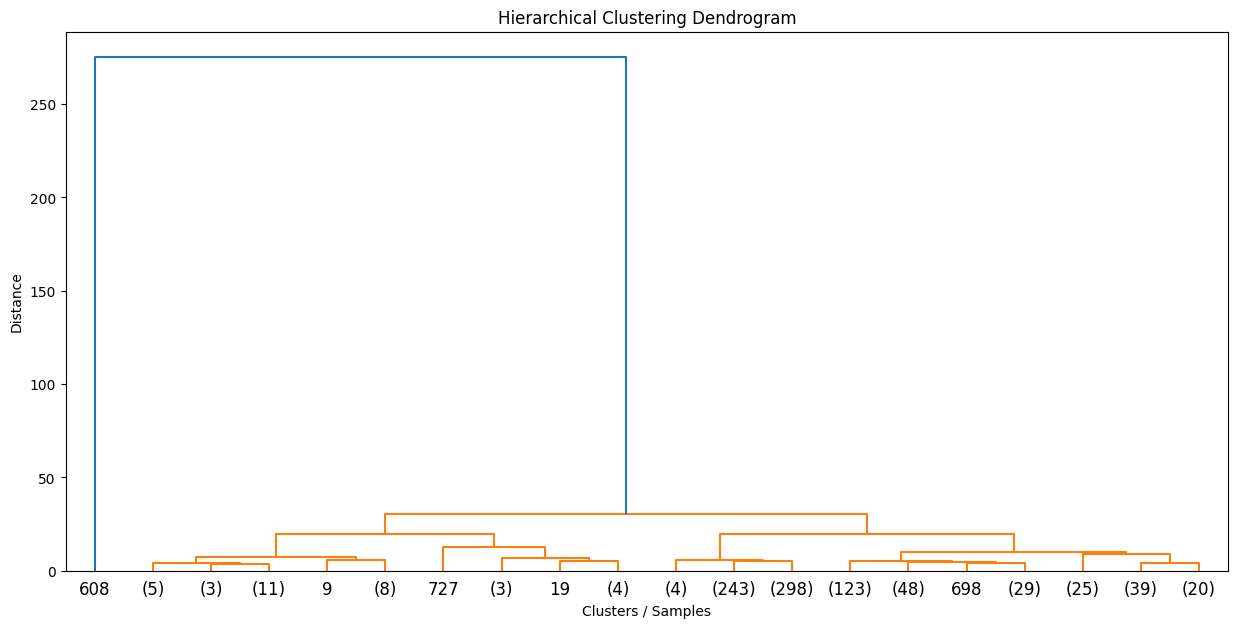

In [35]:
from scipy.cluster.hierarchy import dendrogram,linkage
linked = linkage(X_test_scaled, method='ward')

plt.figure(figsize=(15,7))
dendrogram(linked, truncate_mode ='lastp', p=20)        #Only show the last p levels/groups of the clustering tree.

plt.xlabel("Clusters / Samples")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()
# clearly it will have 2 clusters as best case longest vertical

In [37]:
model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

labels = model.fit_predict(X_test_scaled)

# initialize cluster column for all rows, then assign labels to test-set indices
df["Cluster_AC"] = -1
df.loc[X_test.index, "Cluster_AC"] = labels

print(df["Cluster_AC"].value_counts().sort_index())

Cluster
-1    3471
 0     867
 1       1
Name: count, dtype: int64


K-Means:

"Which centroid are you closest to?"

GMM:

"What is the probability that you belong to each Gaussian distribution?"

So GMM is particularly useful when clusters overlap and aren't clean spherical groups.

In [42]:
from sklearn.mixture import GaussianMixture
model = GaussianMixture(n_components = 2, random_state=42)
labels1 = model.fit_predict(X_test_scaled)
print(labels1)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [44]:
df["Cluster_1"] = -1
df.loc[X_test.index, "Cluster_1"] = labels1
print(df['Cluster_1'].value_counts().sort_index())

Cluster_1
-1    3471
 0     867
 1       1
Name: count, dtype: int64


In [45]:
probabilities = model.predict_proba(X_test_scaled)
print(probabilities[:10])

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [47]:
score = silhouette_score(X_test_scaled, labels)
print(score)

0.9932132962849393


In [50]:
silhouette = []
components =  range(2,21)
for n_component in components:
    model = GaussianMixture(n_components=n_component, random_state=42)
    labels = model.fit_predict(X_test_scaled)

    score = silhouette_score(X_test_scaled, labels)
    silhouette.append(score)

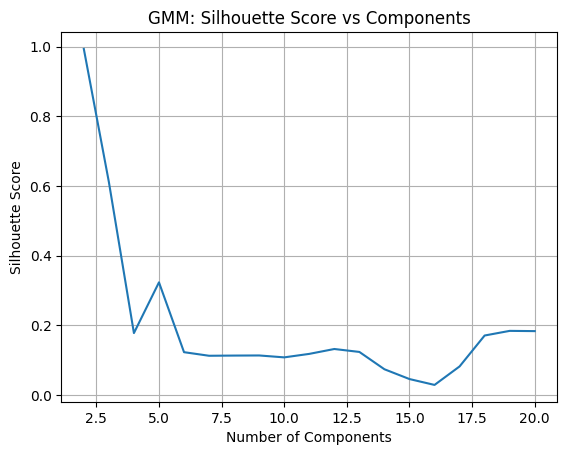

In [53]:
plt.plot(components, silhouette)
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("GMM: Silhouette Score vs Components")

plt.grid()
plt.show()

In [57]:
best_component = components[silhouette.index(max(silhouette))]
print("Best comp. is", best_component) 

Best comp. is 2


In [56]:
max(silhouette)

0.9932132962849393

In [61]:
model=GaussianMixture(n_components = best_component, random_state = 42)
model.fit_predict(X_test_scaled)
labels = model.fit_predict(X_test_scaled)

df["GMM_Cluster"] = -1
df.loc[X_test.index, "GMM_Cluster"] = labels
print(df["GMM_Cluster"].value_counts().sort_index())


GMM_Cluster
-1    3471
 0     867
 1       1
Name: count, dtype: int64


In [66]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_test_scaled)

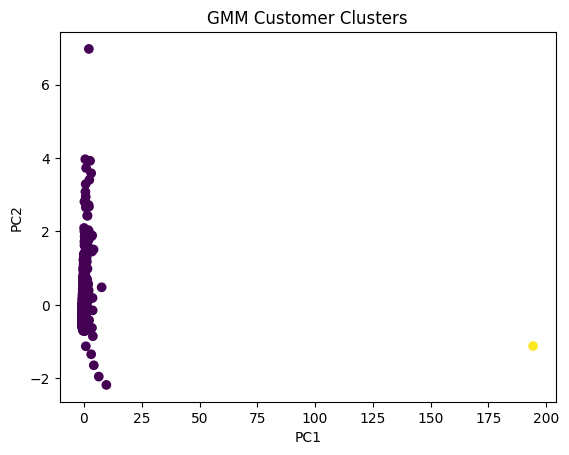

In [68]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Customer Clusters")
plt.show()

Isolation Forest — anomaly detection.

This is different from clustering. We're no longer asking "which group does this customer belong to?"

We're asking:

"Which customers look unusual compared with the rest?

In [69]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators = 200, contamination=0.05 , random_state = 42)
model.fit(X_train_scaled)
labels = model.predict(X_test_scaled)
print(labels[:20])

[ 1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1]


In [72]:
pd.Series(labels).value_counts()
# it 95% to 5% bcz we took contamination = 0.05

 1    822
-1     46
Name: count, dtype: int64

In [76]:
df["Anomaly"] = 1
df.loc[X_test.index, "Anomaly"] = labels
print(df["Anomaly"].value_counts())

Anomaly
 1    4293
-1      46
Name: count, dtype: int64


In [77]:
anomalies = df[df["Anomaly"] == -1]

print(anomalies.head())

     Customer ID  Frequency  TotalQuantity   AvgPrice  ProductCount  \
0              0       1428       841128.0   6.288362          3301   
104        12474         18         9694.0   2.865660           253   
156        12540         17        13370.0   3.847050           277   
315        12731         12        16874.0   3.346168           109   
325        12744          7        10482.0  58.333288           178   

       TotalSpend  HighValue  Cluster  Cluster_1  Cluster_2  Cluster_GMM  \
0    3.510553e+06       True        1          1          1            1   
104  1.475158e+04       True        0          0          0            0   
156  2.680048e+04       True        0          0          0            0   
315  3.779182e+04       True        0          0          0            0   
325  4.255858e+04       True        0          0          0            0   

     GMM_Cluster  Anomaly  
0              1       -1  
104            0       -1  
156            0       -1  
315 

In [80]:
scores = model.decision_function(X_test_scaled)
df["AnomalyScore"] = np.inf
df.loc[X_test.index, "AnomalyScore"] = scores

print(
    df[
        [
            "Customer ID",
            "TotalSpend",
            "Frequency",
            "TotalQuantity",
            "AnomalyScore"
        ]
    ].sort_values("AnomalyScore")
    .head(10)
)


      Customer ID    TotalSpend  Frequency  TotalQuantity  AnomalyScore
0               0  3.510553e+06       1428       841128.0     -0.312249
3729        17450  3.891016e+05         46       139986.0     -0.233834
4094        17949  1.170210e+05         45        61092.0     -0.208002
796         13408  5.623408e+04         62        32464.0     -0.195119
4022        17857  5.375808e+04         23        38512.0     -0.176171
2518        15769  1.125054e+05         26        59344.0     -0.171816
1780        14769  2.134950e+04          8        14872.0     -0.151065
325         12744  4.255858e+04          7        10482.0     -0.150669
2584        15856  3.277514e+04         27        22010.0     -0.145352
571         13098  5.776488e+04         28        31936.0     -0.135008


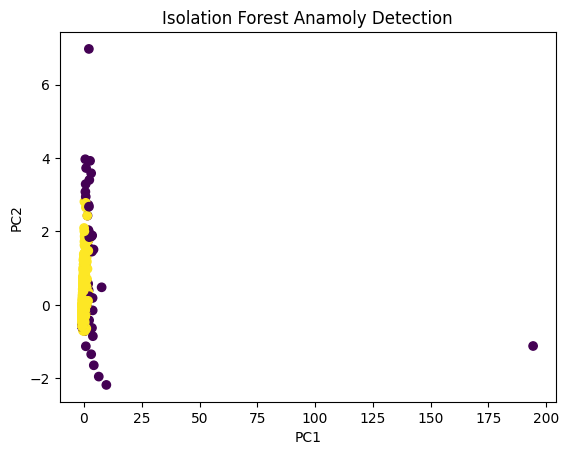

In [81]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_test_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anamoly Detection")
plt.show()

In [82]:
for contamination in [0.01, 0.03, 0.05, 0.10]:

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )

    labels = model.fit_predict(X_test_scaled)

    print(
        contamination,
        "→ anomalies:",
        (labels == -1).sum()
    )

0.01 → anomalies: 9
0.03 → anomalies: 27
0.05 → anomalies: 44
0.1 → anomalies: 87


In [83]:
X = df[
    [
        "Frequency",
        "TotalQuantity",
        "AvgPrice",
        "ProductCount"
    ]
]

In [84]:
pca_1 = PCA()
X_pca = pca_1.fit_transform(X_test_scaled)

In [85]:
print(pca_1.explained_variance_ratio_)

[9.83518690e-01 1.14484637e-02 4.45244157e-03 5.80404849e-04]


In [88]:
cum = (np.cumsum(pca_1.explained_variance_ratio_))
print(cum)

[0.98351869 0.99496715 0.9994196  1.        ]


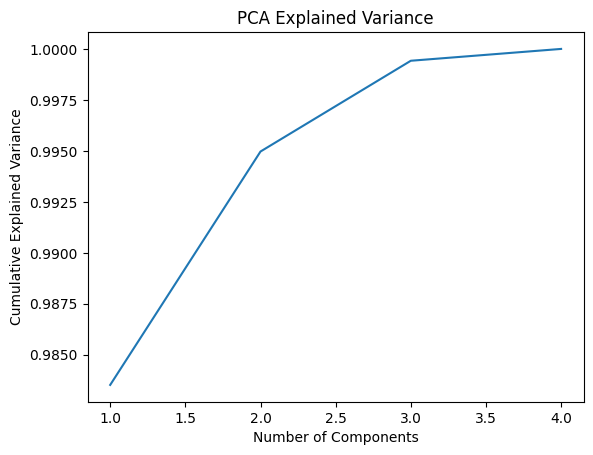

In [90]:
plt.plot(
    range(1,len(cum)+1), cum)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [91]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_test_scaled)

print("Original shape:", X_test_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (868, 4)
PCA shape: (868, 2)


In [ ]:
df["GMM_Cluster"] = -1
df.loc[X_test.index, "GMM_Cluster"] = labels
print(df["GMM_Cluster"].value_counts().sort_index())


In [93]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
labels = model.fit_predict(X_pca)
df["PCA_Cluster"] = 1
df.loc[X_test.index, "PCA_Cluster"] = labels
print(df["PCA_Cluster"].value_counts().sort_index())

PCA_Cluster
0     745
1    3472
2     110
3      12
Name: count, dtype: int64


In [94]:
score = silhouette_score(
    X_pca,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.674148935310659


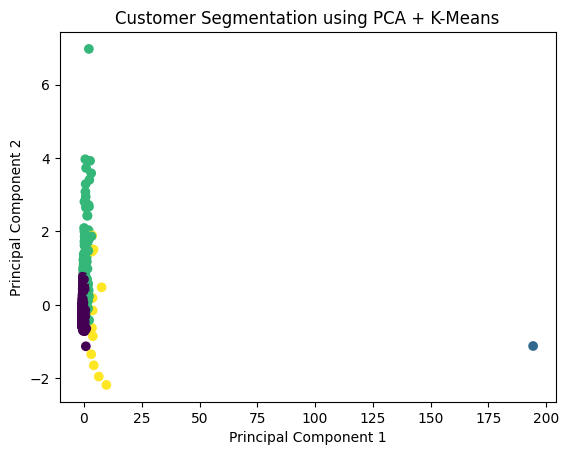

In [95]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using PCA + K-Means")

plt.show()

In [96]:
silhouette_scores = []

K = range(2, 11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    silhouette_scores.append(score)

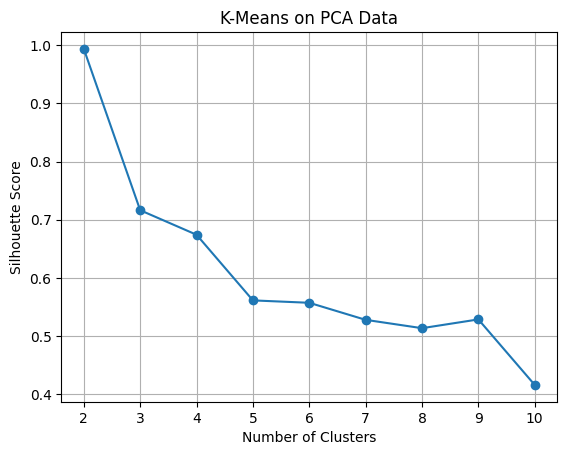

In [97]:
plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means on PCA Data")

plt.grid()
plt.show()

In [98]:
best_k = K[
    silhouette_scores.index(
        max(silhouette_scores)
    )
]

print("Best K:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K: 2
Best Silhouette Score: 0.9935604864932936


In [101]:
model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_pca)

df["Final_cluster"] = 1
df.loc[X_test.index, "Final_cluster"] = labels

print(df["Final_cluster"].value_counts().sort_index())

Final_cluster
0     867
1    3472
Name: count, dtype: int64


PCA (reduces dimensions + makes data easier to visualize/process)

K-Means + actually creates clusters

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [8]:
pipeline = Pipeline([("scaler", StandardScaler()), ("model",LogisticRegression(max_iter=1000))])

In [9]:
pipeline.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Frequency','TotalQuantity','AvgPrice','ProductCount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [10]:
Y_pred = pipeline.predict(X_test)
print(Y_pred)

[False False False False False False False False False  True False False
 False False False False False False False  True False  True False  True
 False False False False False False  True False False False False  True
 False False  True False False False False False False False False  True
  True  True False  True False False False False False  True False False
  True False  True False False False False False False False False False
 False False  True  True False False  True  True False False False False
 False False False  True False False  True False False False False False
 False False False False  True False False False  True False False False
 False  True  True  True False False False False  True  True False False
 False False False False False False False  True False  True False False
 False False False  True False False  True False  True False False False
 False False False False  True  True False False  True  True False False
 False False False False  True False False False Fa

In [11]:
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
print(accuracy_score(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.923963133640553
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       651
        True       0.90      0.78      0.84       217

    accuracy                           0.92       868
   macro avg       0.92      0.88      0.89       868
weighted avg       0.92      0.92      0.92       868



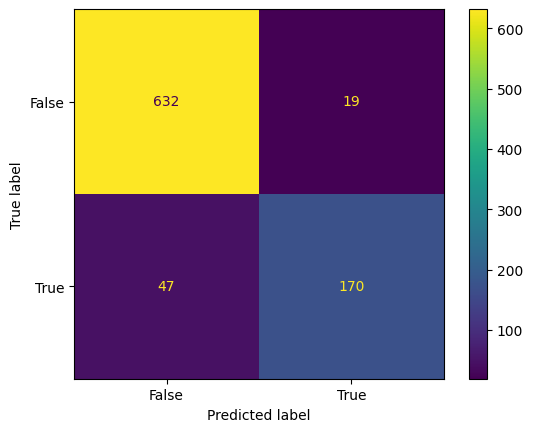

In [12]:
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)

In [13]:
from sklearn.model_selection import GridSearchCV
params = {'model__C': [0.01, 0.1, 1, 10, 100]}     #step_name__parameter ie model is name of logi reg and C is logistic reg. parameter

grid = GridSearchCV(pipeline, params, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [14]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'model__C': 100}
Best CV Accuracy: 0.9403603342110174


In [15]:
best_model = grid.best_estimator_           #best_model is the entire pipeline, not just Logistic Regression.
y_pred = best_model.predict(X_test)
print(
    "Test Accuracy:",
    accuracy_score(Y_test, y_pred)
)

Test Accuracy: 0.9228110599078341


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [17]:
numeric_features = [
    "Frequency",
    "TotalQuantity",
    "AvgPrice",
    "ProductCount"
]

categorical_features = [
    "Country"
]

In [23]:
preprocessor = ColumnTransformer([("num",StandardScaler(),numeric_features) , ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])

Take the numerical columns → scale them.

Take categorical columns → convert categories into 0/1 columns.

handle_unknown="ignore" is important because the test set might contain a category that wasn't present in training.

In [ ]:
print(X_train.columns.tolist())
# as there is no country in these columns so we cant use country 

['Frequency', 'TotalQuantity', 'AvgPrice', 'ProductCount']


In [28]:
preprocessor = ColumnTransformer([("num",StandardScaler(),numeric_features)])

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([("preprocessor",preprocessor) , ("model",LogisticRegression(max_iter=1000))])
pipeline.fit(X_train, Y_train)
y_pred1 = pipeline.predict(X_test)

In [29]:
accuracy_score(Y_test, y_pred1)

0.923963133640553

In [30]:
from sklearn.model_selection import GridSearchCV
params = {'model__C': [0.01, 0.1, 1, 10, 100]}     #step_name__parameter ie model is name of logi reg and C is logistic reg. parameter

grid = GridSearchCV(pipeline, params, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [31]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'model__C': 100}
Best CV Accuracy: 0.9403603342110174


In [34]:
best_model = grid.best_estimator_           #best_model is the entire pipeline, not just Logistic Regression.
y_pred_ct = best_model.predict(X_test)
print(
    "Test Accuracy:",
    accuracy_score(Y_test, y_pred_ct)
)

Test Accuracy: 0.9228110599078341
